# ج

In [1]:
import numpy as np
import cv2 as cv

# termination criteria
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(6,9,0)
objp = np.zeros((7*10,3), np.float32)
objp[:,:2] = np.mgrid[0:7,0:10].T.reshape(-1,2)

# Arrays to store object points and image points from all the images.
objpoints = [] # 3d point in real world space
imgpoints = [] # 2d points in image plane.

for num in range(1, 11):
    img = cv.imread(f'calibration_pattern_images/{num}.jpg')
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Find the chess board corners
    ret, corners = cv.findChessboardCorners(gray, (7,10), None)

    # If found, add object points, image points (after refining them)
    if ret == True:
        objpoints.append(objp)

        corners2 = cv.cornerSubPix(gray,corners, (11,11), (-1,-1), criteria)
        imgpoints.append(corners2)

        # Draw and display the corners
        cv.drawChessboardCorners(img, (7,10), corners2, ret)
        cv.imwrite(f'calibration_pattern_images/calibration_points_{num}.png', img) 
        cv.imshow('calibration image with points', img)
        cv.waitKey(0)
cv.destroyAllWindows()


libGL error: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: iris
libGL error: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: iris
libGL error: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: swrast


In [2]:
ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)

print(mtx) 
print(dist) 


[[1.01924785e+03 0.00000000e+00 3.63107589e+02]
 [0.00000000e+00 1.01471643e+03 6.27822865e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
[[ 0.27779138 -0.5990963  -0.00426412  0.00517476 -2.93037247]]


# د

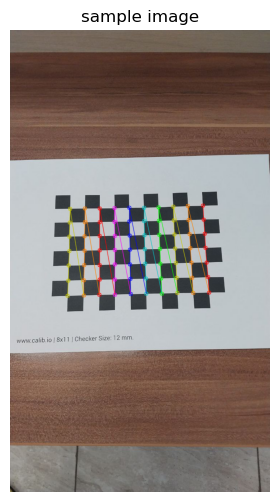

[25.32612031]


In [3]:
import matplotlib.pyplot as plt 

index = 9

sample_img = cv.imread(f'calibration_pattern_images/calibration_points_{index}.png', cv.IMREAD_COLOR)
sample_img = cv.cvtColor(sample_img, cv.COLOR_BGR2RGB) 

plt.figure(figsize=(8, 6))
plt.imshow(sample_img, cmap='gray') 
plt.title('sample image')
plt.axis('off')

plt.show() 

print(tvecs[index - 1][2])
